# Laboratorio de Control Térmico: Diseño de PID


In [134]:
import tclab
import control as cs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter

## Simulación para el sistema en oscilaciones perpetuas

Vamos a realizar como primer paso la simulación de nuestro sistema termico sin tiempo muerto, de modo que podamos observar un comportamiento base a nuestra planta realizada.

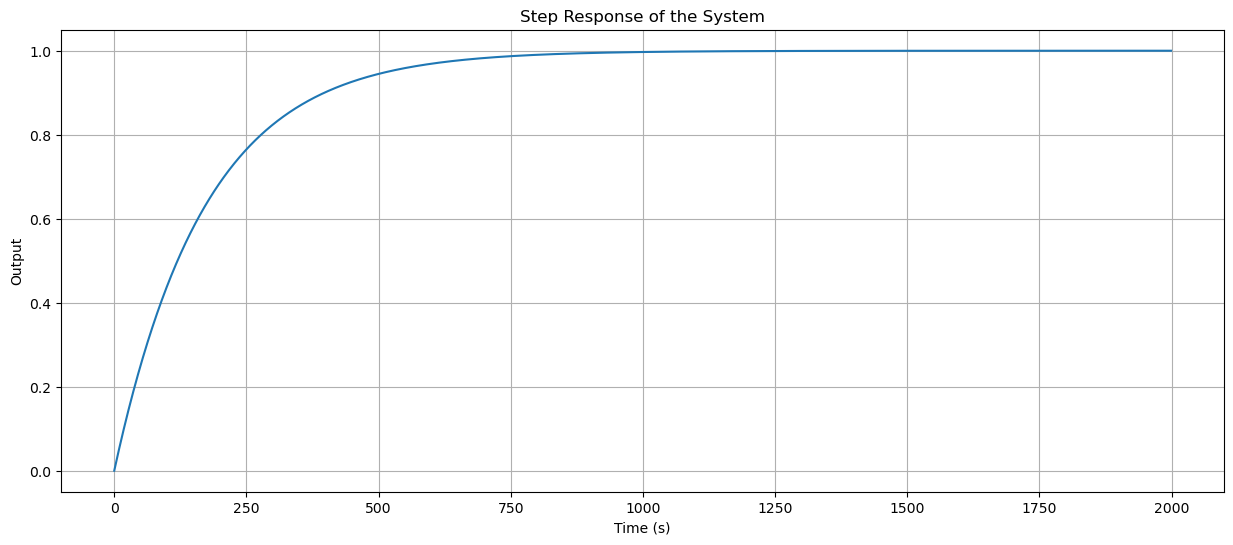

In [135]:
    # Instance of our transfer function
k = 1
tau = 172.61
theta = 20.76

# Making no-dead time transfer function
G = cs.TransferFunction([k], [tau, 1])

# Time vector
t = range(0, 2000) # 0 to 2000 seconds

# Step response
t, y = cs.step_response(G, t)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(t, y)
plt.title('Step Response of the System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()


Para ahora nuevamente ver nuestra respuesta con respecto a una retroalimentación y variando nuestra ganancia K.

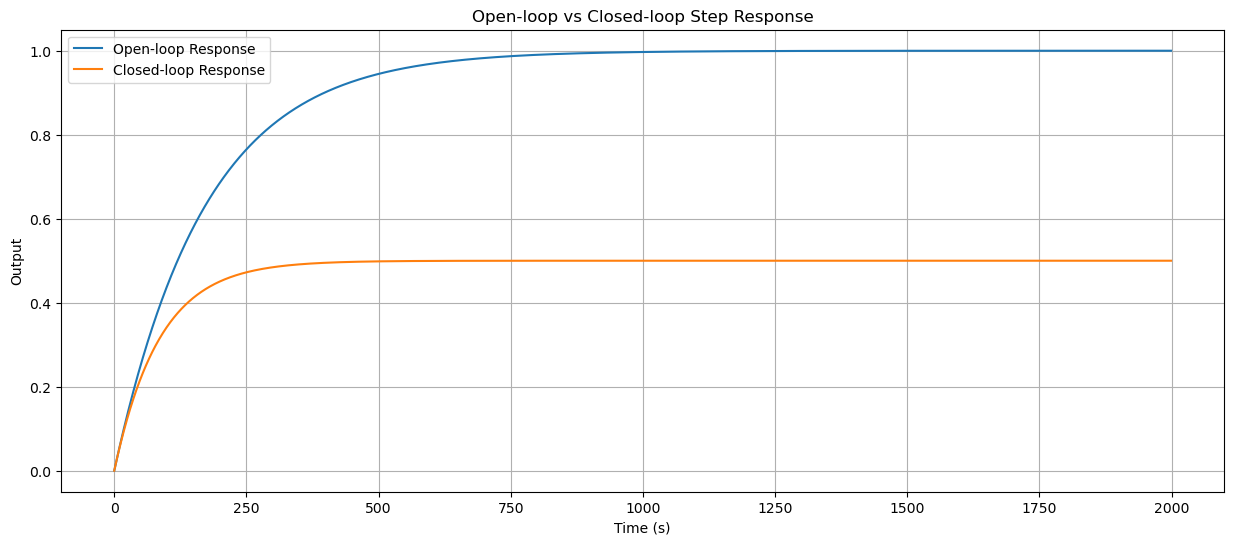

In [136]:
# Define new transfer function
Gs = cs.TransferFunction([k], [tau, 1])

# Define controller for Gs
Controller = cs.TransferFunction([1], [1])  # Proportional controller with gain 1

# Closed-loop transfer function
Closed_Loop = cs.feedback(Controller * Gs, 1)

# Step response of closed-loop system
t_cl, y_cl = cs.step_response(Closed_Loop, t)

# Plotting closed-loop response & open-loop response
plt.figure(figsize=(15, 6))
plt.plot(t, y, label='Open-loop Response')
plt.plot(t_cl, y_cl, label='Closed-loop Response')
plt.title('Open-loop vs Closed-loop Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.grid()

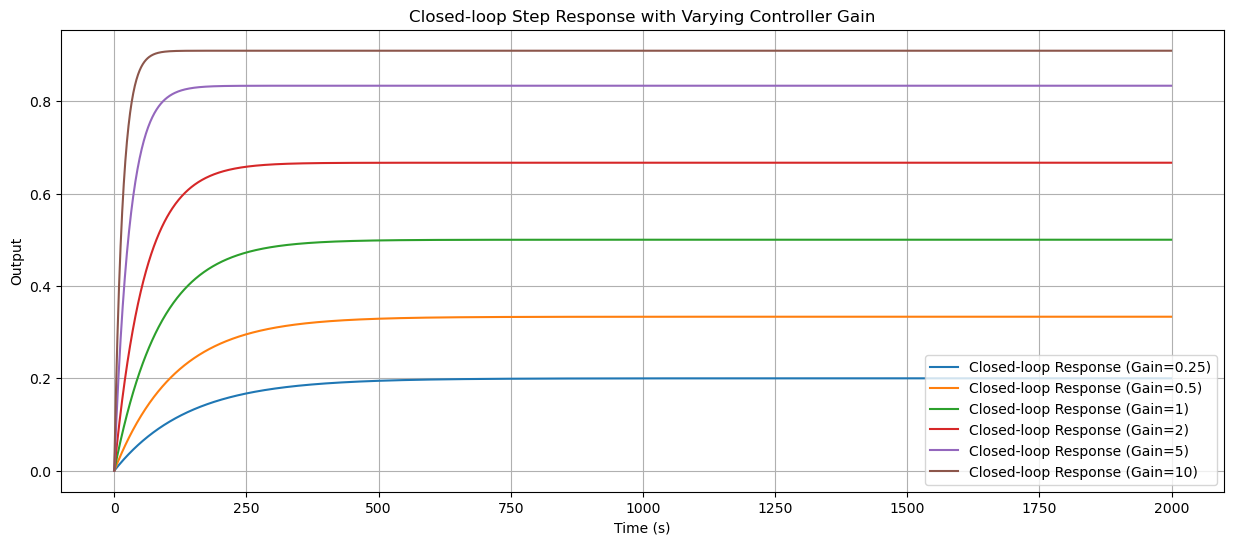

In [137]:
# New plot for the closed-loop response varying its controller value gain
plt.figure(figsize=(15, 6))

for i in [0.25, 0.5, 1, 2, 5, 10]:  # Different controller gains
    Controller = cs.TransferFunction([i], [1])  # Proportional controller with varying gain
    Closed_Loop = cs.feedback(Controller * Gs, 1)  # Closed-loop transfer function
    t_cl, y_cl = cs.step_response(Closed_Loop, t)  # Step response of closed-loop system
    plt.plot(t_cl, y_cl, label=f'Closed-loop Response (Gain={i})')

plt.title('Closed-loop Step Response with Varying Controller Gain')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Realizamos la simulación con tiempo muerto de lo previamente definido para observar oscilaciones en nuestro sistema.

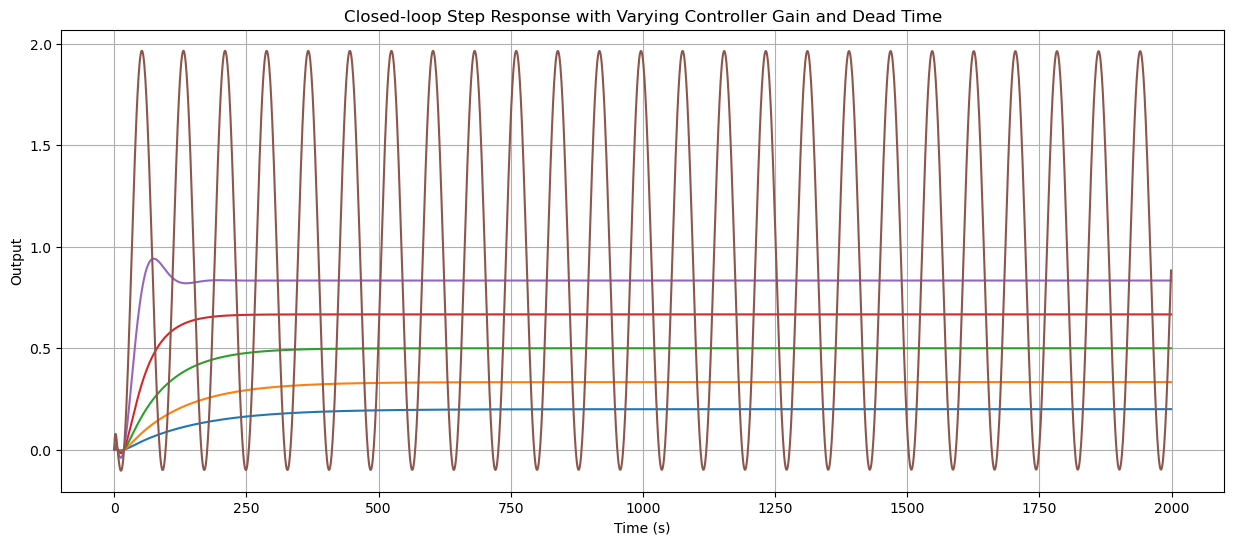

In [138]:
# Define new transfer function with dead time using Pade approximation
num, den = cs.pade(theta, 2)  # Pade approximation of dead time
Gs_dead_time = cs.TransferFunction(num, den) * Gs # System with dead time

# System configuration done with closed-loop control and proportional pure action
plt.figure(figsize=(15, 6))

for i in [0.25, 0.5, 1, 2, 5, 13.82]:  # Different controller gains - by varying the last value for the brown trace, we define 17.752 as a Ke
    Controller = cs.TransferFunction([i], [1])  # Proportional controller with varying gain
    Closed_Loop = cs.feedback(Controller * Gs_dead_time, 1)  # Closed-loop transfer function

# Step response of closed-loop system
    t_cl, y_cl = cs.step_response(Closed_Loop, t)  # Step response of closed-loop system
    plt.plot(t_cl, y_cl, label=f'Closed-loop Response with Dead Time (Gain={i})')

plt.title('Closed-loop Step Response with Varying Controller Gain and Dead Time')
plt.xlabel('Time (s)')
plt.ylabel('Output')
# Limit x-axis to better visualize the response
#plt.xlim(33,112)  
plt.grid()
plt.show()




Acorde a la variación de nuestro valores podemos decir que:

$$K_u \approx 13.82$$

$$P_u \approx 80s $$

Estimados desde la misma grafica ampliando los limites de esta y la ganancia por tanteo.

## Comprobación real del sistema desde una ganancia acorde para las oscilaciones del sistema

Desde un valor estimado en la práctica alrededor de los $300-750$ en $K_u$ pudimos observar el sistema oscilar de forma perpetua en la realidad, trabajamos con el valor de 750 donde podiamos observar las oscilaciones acordes a un rango definido y que hubiera tambien un poco de saturación para lograr llegar a esa respuesta de oscilación esperado, esto con el fin de no observar estos picos descendiendo o ascendiendo puesto que tendriamos un problema al aplicar ese valor de ganancia.

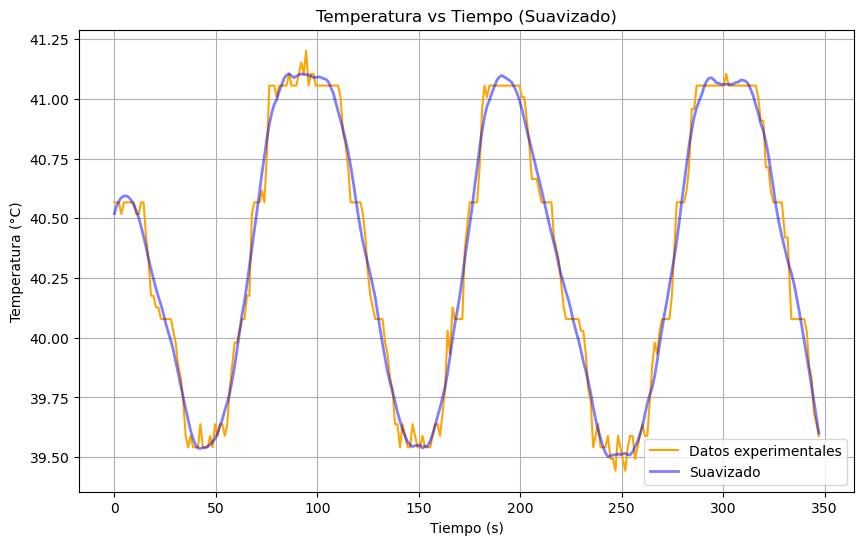

In [139]:
# Open file
data = pd.read_csv('data_lab4/data_oscilacion.txt', encoding='latin1', sep=',')

# Extract data
time = data['Tiempo (s)']
temperature = data[' Temp1 (°C)']

# Softer curve using Savitzky-Golay filter
temperature_smooth = savgol_filter(temperature, window_length=21, polyorder=3)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, temperature, label='Datos experimentales', color='orange', alpha=1)
plt.plot(time, temperature_smooth, label='Suavizado', color='blue', linewidth=2, alpha=0.5)

plt.title('Temperatura vs Tiempo (Suavizado)')
plt.xlabel('Tiempo (s)')
#plt.xlim(12, 120) 
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid()
plt.show()


El comportamiento que se puede observar en esta gráfica responde a un $K_u = 750$, el cual observamos cono en ciertos puntos se ve un poco de saturación de pico a pico, pero por practicidad es la mejor respuesta que llega de borde a borde en la oscilación, algo que se le puede atribuir a que la respuesta no fue diferente o se evito con respecto a las saturaciones dadas es la posibilidad de factores externos haciendo que las medidas no se precisen más de lo que ya se obtiene, puesto que al poner en prueba nuestro sistema con la fuente en el laboratorio de potencia observamos una respecto con respecto a ese ambiente, mientras que en el laboratorio de basicas fue distinto (mismo caso expuesto en la práctica 1).

Recolectando los datos nuevos para el sistema en oscilación real tenemos

$$K_u = 750$$

$$P_u \approx 108 \ s$$

# Diseño del Controlador 

## Simulación para el control PID

Con nuestros parametros previamente calculados de $K_u$ y $P_u$, definimos nuestros parametros para el PID con Ziegler Nichols.

$$K_p \approx 8.3$$

$$T_i \approx 40s$$

$$T_d \approx 10s$$

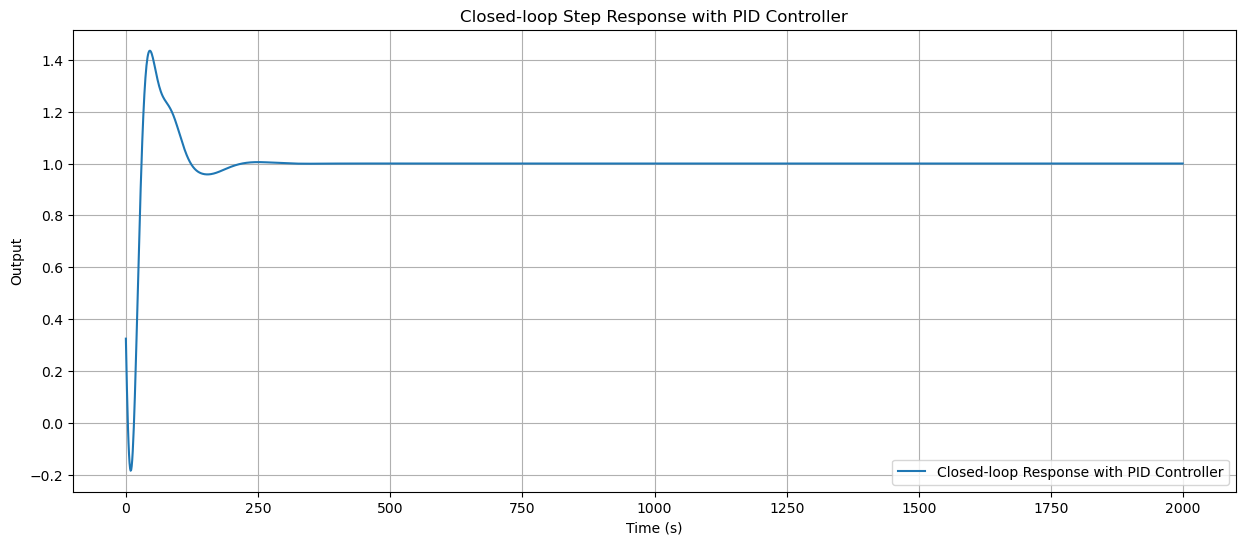

In [140]:
K_u = 13.82 # Gain from simulation for oscillations with pure proportional control
K_p = 0.6 * K_u # Gain for PID controller using Ziegler-Nichols tuning rules
T_i = 40
T_d = 10

# Calculate integral and derivative gains
K_i = K_p / T_i
K_d = K_p * T_d

# Design transfer function for PID controller
num = [K_d, K_p, K_i]  # PID controller numerator coefficients
den = [1, 0]  # PID controller denominator coefficients (s^2 term for derivative action)

PID_Controller = cs.TransferFunction(num, den)
Closed_Loop_PID = cs.feedback(PID_Controller * Gs_dead_time, 1)

# Step response of closed-loop system with PID controller
t_cls, y_cls = cs.step_response(Closed_Loop_PID, t)

# Plotting closed-loop response with PID controller
plt.figure(figsize=(15, 6))
plt.plot(t_cls, y_cls, label='Closed-loop Response with PID Controller')
plt.title('Closed-loop Step Response with PID Controller')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend(loc='lower right')
plt.grid()

## Comprobación real del funcionamiento del PID

Con nuestros parametros previamente calculados de $K_u$ y $P_u$ pero esta vez de nuestra planta real, definimos nuestros parametros para el PID con Ziegler Nichols y así asemejarnos a una respuesta esperada para el sistema.


$$K_p = 750$$

$$T_i = 54 \ s$$

$$T_d = 13.5$$


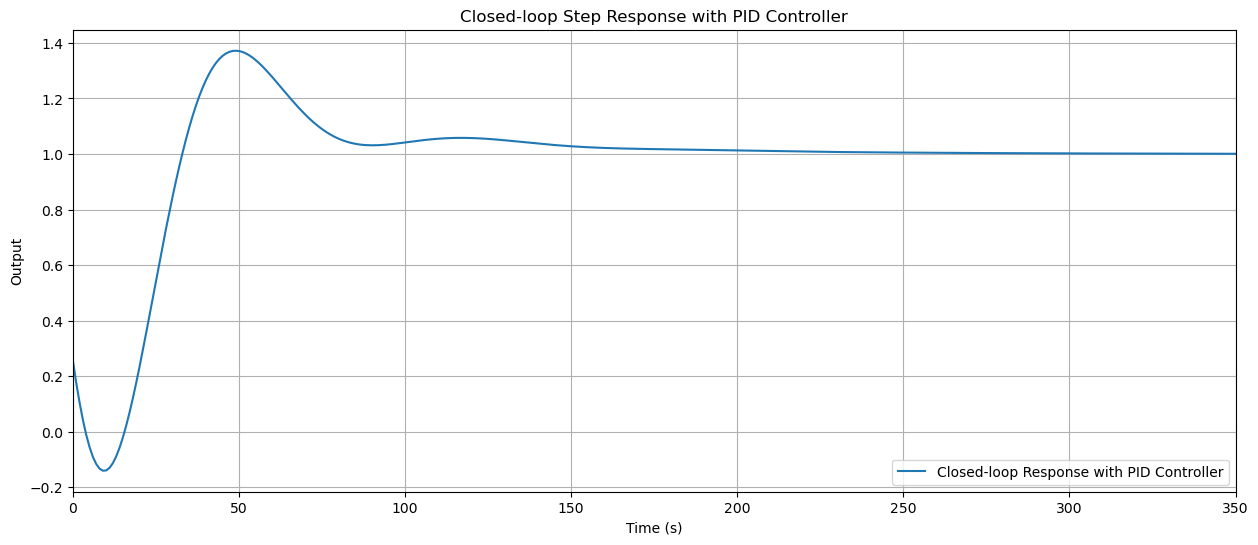

In [141]:
# FINE TUNING THE PID VALUES FOR A BETTER RESPONSE TO OUR SYSTEM
K_u = 750
K_p = 0.0115 * K_u
T_i = 1.5 * 54
T_d = 0.5 * 13.5

# Calculate integral and derivative gains
K_i = K_p / T_i
K_d = K_p * T_d

# Design transfer function for PID controller
num = [K_d, K_p, K_i]  # PID controller numerator coefficients
den = [1, 0]  # PID controller denominator coefficients (s^2 term for derivative action)

PID_Controller = cs.TransferFunction(num, den)
Closed_Loop_PID = cs.feedback(PID_Controller * Gs_dead_time, 1)

# Step response of closed-loop system with PID controller
t_cl, y_cl = cs.step_response(Closed_Loop_PID, t)

# Plotting closed-loop response with PID controller
plt.figure(figsize=(15, 6))
plt.plot(t_cl, y_cl, label='Closed-loop Response with PID Controller')
plt.title('Closed-loop Step Response with PID Controller')
plt.xlabel('Time (s)')
plt.xlim(0, 350)
plt.ylabel('Output')
plt.legend(loc='lower right')
plt.grid()

Se realizó un ajuste empírico de $K_p$, observando la respuesta al escalón. Se encontró que valores menores a 
$0.6K_u$ reducen el sobreimpulso y eliminan oscilaciones sostenidas, logrando un comportamiento más estable utlizando la ganancia máxima considerada en la práctica.

## Aplicando en el sistema real

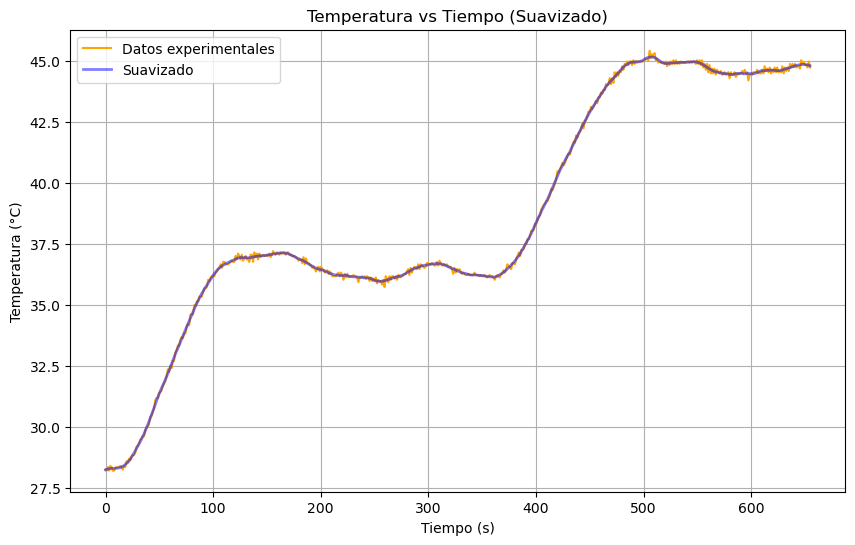

In [148]:
# Open file
data = pd.read_csv('data_lab4/data_PID.txt', encoding='latin1', sep=',')

# Extract data
time = data['Tiempo (s)']
temperature = data[' Temp1 (°C)']

# Softer curve using Savitzky-Golay filter
temperature_smooth = savgol_filter(temperature, window_length=21, polyorder=3)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, temperature, label='Datos experimentales', color='orange', alpha=1)
plt.plot(time, temperature_smooth, label='Suavizado', color='blue', linewidth=2, alpha=0.5)

plt.title('Temperatura vs Tiempo (Suavizado)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
#plt.xlim(200, 350)
#plt.ylim(35,37)
plt.legend()
plt.grid()
plt.show()

In [143]:
# Cargar datos
data = pd.read_csv('data_lab4/data_PID.txt', encoding='latin1', sep=',')

# Extraer variables
t = data['Tiempo (s)'].values
y = data[' Temp1 (°C)'].values

# Definir setpoint
sp = np.zeros_like(t)
sp[t < 350] = 35
sp[t >= 350] = 45

# Detectar cambio automáticamente
cambio = np.where(np.diff(sp) > 5)[0][0]

# TRAMO 1 (35°C)
y1 = y[:cambio]
t1 = t[:cambio]

y1_ini = y1[0]
y1_final = 35
y1_max = np.max(y1)

OS1 = (y1_max - y1_final) / (y1_final - y1_ini) * 100


# TRAMO 2 (45°C)
y2 = y[cambio:]
t2 = t[cambio:]

y2_ini = y2[0]
y2_final = 45
y2_max = np.max(y2)

OS2 = (y2_max - y2_final) / (y2_final - y2_ini) * 100

print(f"Sobreimpulso a 35°C: {OS1:.2f}%")
print(f"Sobreimpulso a 45°C: {OS2:.2f}%")


Sobreimpulso a 35°C: 32.52%
Sobreimpulso a 45°C: 4.60%


El sobreimpulso nos indica la efectividad del controlador PID en función de la sintonización aplicada, ya que refleja qué tan agresiva es la respuesta del sistema frente a un cambio en la consigna. En sistemas térmicos, debido a su naturaleza lenta y a que generalmente no requieren respuestas extremadamente rápidas, un sobreimpulso en el rango del 20–30% suele considerarse aceptable cuando no se tiene un criterio estricto de precisión. Esto se debe a que pequeñas desviaciones por encima del valor deseado no representan un problema crítico, especialmente en ausencia de perturbaciones externas significativas o mecanismos adicionales de regulación, como ventilación forzada, que podrían mitigar dichas variaciones.

Adicionalmente, es importante analizar el comportamiento en estado estacionario, ya que este permite evaluar la precisión final del sistema controlado. Para ello, resulta útil acotar los límites de la gráfica y observar con mayor detalle la región donde la señal se estabiliza. En este caso, para el primer punto de consigna se observa una estabilización alrededor de 0.75 °C respecto al valor deseado, lo que corresponde aproximadamente a un error del 2% en estado estacionario. Este valor se encuentra dentro de márgenes comúnmente aceptados en sistemas térmicos, lo cual indica que el controlador logra no solo una respuesta transitoria adecuada, sino también una buena precisión en estado estacionario.

En conjunto, estos resultados sugieren que la sintonización del PID alcanza un compromiso adecuado entre rapidez de respuesta, sobreimpulso y error estacionario, lo cual es fundamental en sistemas térmicos donde la estabilidad y la robustez suelen ser más importantes que una respuesta excesivamente rápida.